# Project Phase 1 

In [137]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [138]:
# fetching the data and creating dataFrame
job_postings_dataset = pd.read_csv("job_postings.csv")
job_postings_dataframe = pd.DataFrame(job_postings_dataset)

# checking the information of dataframe
job_postings_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15886 entries, 0 to 15885
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   job_id                      15886 non-null  int64  
 1   company_id                  15520 non-null  float64
 2   title                       15886 non-null  object 
 3   description                 15885 non-null  object 
 4   max_salary                  5521 non-null   float64
 5   med_salary                  981 non-null    float64
 6   min_salary                  5521 non-null   float64
 7   pay_period                  6502 non-null   object 
 8   formatted_work_type         15886 non-null  object 
 9   location                    15886 non-null  object 
 10  applies                     8700 non-null   float64
 11  original_listed_time        15886 non-null  float64
 12  remote_allowed              2340 non-null   float64
 13  views                       131

In [139]:
#  finding the number of fetaures and rows of the data
job_postings_dataframe.shape

(15886, 27)

In [140]:
#  finding the statistic of the given dataset for better analysis
job_postings_dataframe.describe()

,job_id,company_id,max_salary,med_salary,min_salary,applies,original_listed_time,remote_allowed,views,expiry,closed_time,listed_time,sponsored
count,1.588600e+04,1.552000e+04,5.521000e+03,981.000000,5521.000000,8700.000000,1.588600e+04,2340.0,13123.000000,1.588600e+04,9.280000e+02,1.588600e+04,15886.000000
mean,3.691293e+09,1.084100e+07,8.833622e+04,41167.664404,62352.218073,22.833103,1.690000e+12,1.0,76.776575,1.700765e+12,1.690000e+12,1.690000e+12,0.289248
std,1.028617e+08,2.313688e+07,9.068282e+04,93682.094905,59487.692283,54.892826,0.000000e+00,0.0,167.459105,2.709377e+09,0.000000e+00,0.000000e+00,0.453428
min,8.500877e+07,1.009000e+03,1.000000e+01,10.000000,10.000000,1.000000,1.690000e+12,1.0,1.000000,1.690000e+12,1.690000e+12,1.690000e+12,0.000000
25%,3.693071e+09,1.301100e+04,4.800000e+01,18.000000,38.000000,2.000000,1.690000e+12,1.0,6.000000,1.700000e+12,1.690000e+12,1.690000e+12,0.000000
50%,3.697358e+09,2.777685e+05,8.200000e+04,26.000000,60000.000000,6.000000,1.690000e+12,1.0,25.000000,1.700000e+12,1.690000e+12,1.690000e+12,0.000000
75%,3.699413e+09,7.798499e+06,1.400000e+05,52000.000000,99000.000000,21.000000,1.690000e+12,1.0,78.000000,1.700000e+12,1.690000e+12,1.690000e+12,1.000000
max,3.701374e+09,9.856222e+07,1.300000e+06,998426.000000,800000.000000,1615.000000,1.690000e+12,1.0,5656.000000,1.710000e+12,1.690000e+12,1.690000e+12,1.000000


In [141]:
#  finding null value in each of the features in dataset
missing_values = job_postings_dataframe.isnull()
for columns in missing_values.columns.values.tolist():
    print(missing_values[columns].value_counts(),end="\n")


job_id
False    15886
Name: count, dtype: int64
company_id
False    15520
True       366
Name: count, dtype: int64
title
False    15886
Name: count, dtype: int64
description
False    15885
True         1
Name: count, dtype: int64
max_salary
True     10365
False     5521
Name: count, dtype: int64
med_salary
True     14905
False      981
Name: count, dtype: int64
min_salary
True     10365
False     5521
Name: count, dtype: int64
pay_period
True     9384
False    6502
Name: count, dtype: int64
formatted_work_type
False    15886
Name: count, dtype: int64
location
False    15886
Name: count, dtype: int64
applies
False    8700
True     7186
Name: count, dtype: int64
original_listed_time
False    15886
Name: count, dtype: int64
remote_allowed
True     13546
False     2340
Name: count, dtype: int64
views
False    13123
True      2763
Name: count, dtype: int64
job_posting_url
False    15886
Name: count, dtype: int64
application_url
False    9795
True     6091
Name: count, dtype: int64
applicati

In [142]:
#  Drop duplicates values if present and keep the lastest value
job_postings_dataframe.drop_duplicates(keep='last', inplace=True)


In [143]:
# fill the columns like applies or views with 0 if blank for handling missing data 
job_postings_dataframe['applies'].fillna(0, inplace=True)
job_postings_dataframe['views'].fillna(0, inplace=True)
job_postings_dataframe['remote_allowed'].fillna(0, inplace=True)


In [144]:
# Text formatting for string type columns to make data consistent
job_postings_dataframe.loc[:, 'formatted_work_type'] = job_postings_dataframe.loc[:, 'formatted_work_type'].str.upper()
job_postings_dataframe.loc[:, 'work_type'] = job_postings_dataframe.loc[:, 'work_type'].str.upper()
job_postings_dataframe.loc[:, 'formatted_experience_level'] = job_postings_dataframe.loc[:, 'formatted_experience_level'].str.upper()
job_postings_dataframe.loc[:, 'application_type'] = job_postings_dataframe.loc[:, 'application_type'].str.upper()

In [145]:
# Encode categorical values using Label encoding
job_postings_dataframe.loc[:, 'formatted_work_type'] = job_postings_dataframe.loc[:, 'formatted_work_type'].astype('category').cat.codes
job_postings_dataframe.loc[:, 'work_type'] = job_postings_dataframe.loc[:, 'work_type'].astype('category').cat.codes
job_postings_dataframe.loc[:, 'job_posting_url'] = job_postings_dataframe.loc[:, 'job_posting_url'].astype('category').cat.codes
job_postings_dataframe.loc[:, 'application_url'] = job_postings_dataframe.loc[:, 'application_url'].astype('category').cat.codes
job_postings_dataframe.loc[:, 'posting_domain'] = job_postings_dataframe.loc[:, 'posting_domain'].astype('category').cat.codes

In [146]:
# data type conversion from number to date time  for Data time fields
def convert_to_datetime(dataFrame, columnName):
    dataFrame[columnName] = dataFrame[columnName].astype(float)
    dataFrame[columnName] = pd.to_datetime(dataFrame[columnName], unit='ms')

convert_to_datetime(job_postings_dataframe, 'expiry')
convert_to_datetime(job_postings_dataframe, 'original_listed_time')
convert_to_datetime(job_postings_dataframe, 'listed_time')
convert_to_datetime(job_postings_dataframe, 'closed_time')

job_postings_dataframe

,job_id,company_id,title,description,max_salary,med_salary,min_salary,pay_period,formatted_work_type,location,...,expiry,closed_time,formatted_experience_level,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type
0,85008768,NaN,Licensed Insurance Agent,While many industries were hurt by the last fe...,52000.0,NaN,45760.0,YEARLY,1,"Chico, CA",...,2024-03-09 16:00:00,NaT,NaN,NaN,2023-07-22 04:26:40,-1,1,1,USD,BASE_SALARY
1,133114754,77766802.0,Sales Manager,Are you a dynamic and creative marketing profe...,NaN,NaN,NaN,NaN,1,"Santa Clarita, CA",...,2023-11-14 22:13:20,NaT,NaN,NaN,2023-07-22 04:26:40,-1,0,1,NaN,NaN
2,133196985,1089558.0,Model Risk Auditor,Join Us as a Model Risk Auditor – Showcase You...,NaN,NaN,NaN,NaN,0,"New York, NY",...,2023-11-14 22:13:20,NaT,NaN,NaN,2023-07-22 04:26:40,-1,0,0,NaN,NaN
3,381055942,96654609.0,Business Manager,Business ManagerFirst Baptist Church ForneyFor...,NaN,NaN,NaN,NaN,1,"Forney, TX",...,2023-11-14 22:13:20,NaT,NaN,NaN,2023-07-22 04:26:40,-1,0,1,NaN,NaN
4,529257371,1244539.0,NY Studio Assistant,YOU COULD BE ONE OF THE MAGIC MAKERS\nKen Fulk...,NaN,NaN,NaN,NaN,1,"New York, NY",...,2024-03-09 16:00:00,NaT,NaN,NaN,2023-07-22 04:26:40,-1,1,1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15881,3701373516,74718032.0,Sanitation Technician,"Location:\n\nWest Columbia, SC, US, 29172\n\n2...",NaN,NaN,NaN,NaN,4,"West Columbia, SC",...,2023-11-14 22:13:20,NaT,ENTRY LEVEL,NaN,2023-07-22 04:26:40,56,0,4,NaN,NaN
15882,3701373522,38897.0,Unit Secretary,Job Title: Unit Secretary\nDepartment: Nursing...,NaN,NaN,NaN,NaN,1,"Teaneck, NJ",...,2023-11-14 22:13:20,NaT,ENTRY LEVEL,NaN,2023-07-22 04:26:40,985,0,1,NaN,NaN
15883,3701373523,38897.0,"Radiology Aide, Perdiem","Job Title: Radiology Aide, Perdiem\nDepartment...",NaN,NaN,NaN,NaN,4,"Teaneck, NJ",...,2023-11-14 22:13:20,NaT,ENTRY LEVEL,NaN,2023-07-22 04:26:40,985,0,4,NaN,NaN
15884,3701373524,2623.0,MRI Manager,Grade 105\nJob Type: Officer of Administration...,135000.0,NaN,110000.0,YEARLY,1,"New York, NY",...,2023-11-14 22:13:20,NaT,MID-SENIOR LEVEL,NaN,2023-07-22 04:26:40,931,0,1,USD,BASE_SALARY


In [147]:
# Dropping null values (max_salary and min_salary are important to predict , so dropping the null values as they are irrelevant)
job_postings_dataframe.dropna(subset=['max_salary', 'min_salary'], axis=0, inplace=True)


In [148]:
# Inconsistent data handling (Finding  median salary fron max_salary and min_salary where it is absent)
job_postings_dataframe["med_salary"] = job_postings_dataframe.apply(lambda x: 
    (x["max_salary"] + x["min_salary"]) / 2 if x["max_salary"] and x["min_salary"] is not None 
    else x["med_salary"], axis=1)
job_postings_dataframe

,job_id,company_id,title,description,max_salary,med_salary,min_salary,pay_period,formatted_work_type,location,...,expiry,closed_time,formatted_experience_level,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type
0,85008768,NaN,Licensed Insurance Agent,While many industries were hurt by the last fe...,52000.00,48880.000,45760.00,YEARLY,1,"Chico, CA",...,2024-03-09 16:00:00,NaT,NaN,NaN,2023-07-22 04:26:40,-1,1,1,USD,BASE_SALARY
5,903408693,3894635.0,Office Associate,Provide clerical and administrative support to...,42000.00,39500.000,37000.00,YEARLY,1,"Albany, GA",...,2024-03-09 16:00:00,NaT,NaN,NaN,2023-07-22 04:26:40,-1,1,1,USD,BASE_SALARY
8,1029078768,61469.0,Registered Nurse (RN) Vaccinator,United Staffing Solutions is partnering with o...,50.00,50.000,50.00,HOURLY,4,"Muskegon, MI",...,2023-11-14 22:13:20,NaT,NaN,NaN,2023-07-22 04:26:40,-1,0,4,USD,BASE_SALARY
12,1535492735,NaN,Administrative Assistant,We are looking for a responsible Administrativ...,20.00,19.000,18.00,HOURLY,4,"Ocoee, FL",...,2024-03-09 16:00:00,NaT,NaN,NaN,2023-07-22 04:26:40,-1,0,4,USD,BASE_SALARY
13,1657978824,89350959.0,"REMOTE STEEL BUILDING SALES MAKE $1,000 TO $30...","REMOTE WORK FROM HOME $1,000 TO $10,000 COMMIS...",12000.00,12000.000,12000.00,MONTHLY,0,"Texas, United States",...,2024-03-09 16:00:00,NaT,NaN,NaN,2023-07-22 04:26:40,-1,0,0,USD,BASE_SALARY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15870,3701373383,13651.0,Senior Analyst,About Us\nMarketAxess is on a journey to digit...,85000.00,80000.000,75000.00,YEARLY,1,"New York, NY",...,2023-11-14 22:13:20,NaT,MID-SENIOR LEVEL,NaN,2023-07-22 04:26:40,79,0,1,USD,BASE_SALARY
15871,3701373385,18312164.0,Sales Manager,"Sales ManagerTexas, US $60,000–$70,000OTE $250...",70000.00,65000.000,60000.00,YEARLY,1,"Texas, United States",...,2023-11-14 22:13:20,NaT,MID-SENIOR LEVEL,NaN,2023-07-22 04:26:40,-1,0,1,USD,BASE_SALARY
15875,3701373427,1321042.0,Design Intern,Looking to redefine the skyline or to be a par...,23.89,21.485,19.08,HOURLY,2,"Miramar, FL",...,2023-11-14 22:13:20,NaT,MID-SENIOR LEVEL,NaN,2023-07-22 04:26:40,1138,0,2,USD,BASE_SALARY
15878,3701373493,5619.0,Sr. Bilingual Copywriter (Canadian French),Overview\nTHE ROLE:\nThe Senior Bilingual Copy...,105200.00,98550.000,91900.00,YEARLY,1,"Torrance, CA",...,2023-11-14 22:13:20,NaT,MID-SENIOR LEVEL,NaN,2023-07-22 04:26:40,663,0,1,USD,BASE_SALARY


In [149]:
# Data Transformation/ Normalization (the max_salary ,min_salary and med_salary based on the Pay period)
def normalize_pay_period(dataframe, columnName):
    yearly = 1
    monthly = 12
    hourly = 40*52

    dataframe[columnName] = dataframe.apply(lambda x: x[columnName] * hourly if x['pay_period'] == ('HOURLY')
                                            else (x[columnName] * monthly if x['pay_period'] == ('MONTHLY')
                                            else x[columnName] * yearly ), axis=1)
    

normalize_pay_period(job_postings_dataframe, 'max_salary')
normalize_pay_period(job_postings_dataframe, 'min_salary')
normalize_pay_period(job_postings_dataframe, 'med_salary')
job_postings_dataframe['pay_period'] =  'YEARLY'
job_postings_dataframe
    

,job_id,company_id,title,description,max_salary,med_salary,min_salary,pay_period,formatted_work_type,location,...,expiry,closed_time,formatted_experience_level,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type
0,85008768,NaN,Licensed Insurance Agent,While many industries were hurt by the last fe...,52000.0,48880.0,45760.0,YEARLY,1,"Chico, CA",...,2024-03-09 16:00:00,NaT,NaN,NaN,2023-07-22 04:26:40,-1,1,1,USD,BASE_SALARY
5,903408693,3894635.0,Office Associate,Provide clerical and administrative support to...,42000.0,39500.0,37000.0,YEARLY,1,"Albany, GA",...,2024-03-09 16:00:00,NaT,NaN,NaN,2023-07-22 04:26:40,-1,1,1,USD,BASE_SALARY
8,1029078768,61469.0,Registered Nurse (RN) Vaccinator,United Staffing Solutions is partnering with o...,104000.0,104000.0,104000.0,YEARLY,4,"Muskegon, MI",...,2023-11-14 22:13:20,NaT,NaN,NaN,2023-07-22 04:26:40,-1,0,4,USD,BASE_SALARY
12,1535492735,NaN,Administrative Assistant,We are looking for a responsible Administrativ...,41600.0,39520.0,37440.0,YEARLY,4,"Ocoee, FL",...,2024-03-09 16:00:00,NaT,NaN,NaN,2023-07-22 04:26:40,-1,0,4,USD,BASE_SALARY
13,1657978824,89350959.0,"REMOTE STEEL BUILDING SALES MAKE $1,000 TO $30...","REMOTE WORK FROM HOME $1,000 TO $10,000 COMMIS...",144000.0,144000.0,144000.0,YEARLY,0,"Texas, United States",...,2024-03-09 16:00:00,NaT,NaN,NaN,2023-07-22 04:26:40,-1,0,0,USD,BASE_SALARY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15870,3701373383,13651.0,Senior Analyst,About Us\nMarketAxess is on a journey to digit...,85000.0,80000.0,75000.0,YEARLY,1,"New York, NY",...,2023-11-14 22:13:20,NaT,MID-SENIOR LEVEL,NaN,2023-07-22 04:26:40,79,0,1,USD,BASE_SALARY
15871,3701373385,18312164.0,Sales Manager,"Sales ManagerTexas, US $60,000–$70,000OTE $250...",70000.0,65000.0,60000.0,YEARLY,1,"Texas, United States",...,2023-11-14 22:13:20,NaT,MID-SENIOR LEVEL,NaN,2023-07-22 04:26:40,-1,0,1,USD,BASE_SALARY
15875,3701373427,1321042.0,Design Intern,Looking to redefine the skyline or to be a par...,49691.2,44688.8,39686.4,YEARLY,2,"Miramar, FL",...,2023-11-14 22:13:20,NaT,MID-SENIOR LEVEL,NaN,2023-07-22 04:26:40,1138,0,2,USD,BASE_SALARY
15878,3701373493,5619.0,Sr. Bilingual Copywriter (Canadian French),Overview\nTHE ROLE:\nThe Senior Bilingual Copy...,105200.0,98550.0,91900.0,YEARLY,1,"Torrance, CA",...,2023-11-14 22:13:20,NaT,MID-SENIOR LEVEL,NaN,2023-07-22 04:26:40,663,0,1,USD,BASE_SALARY


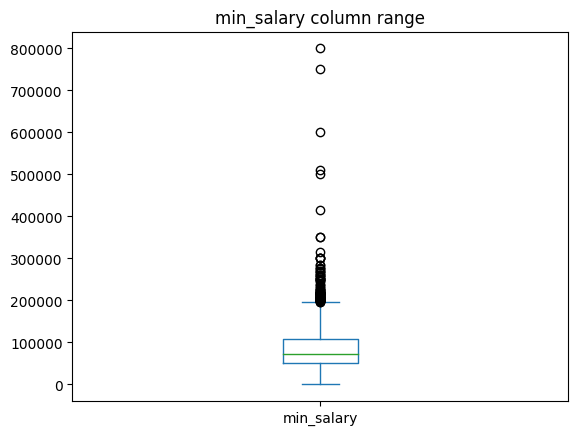

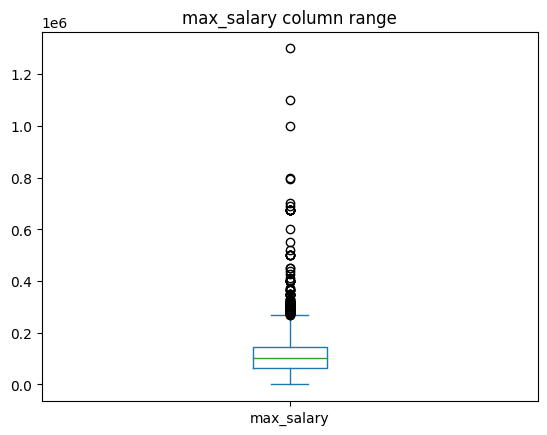

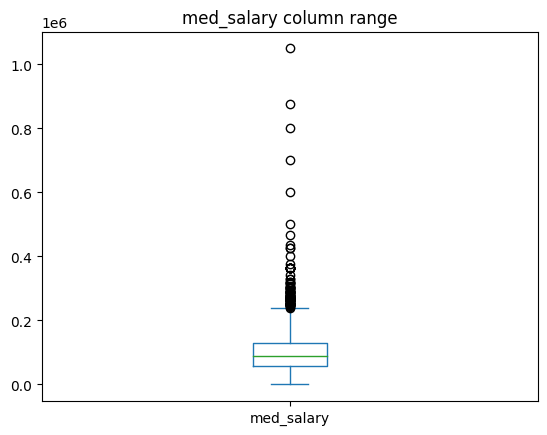

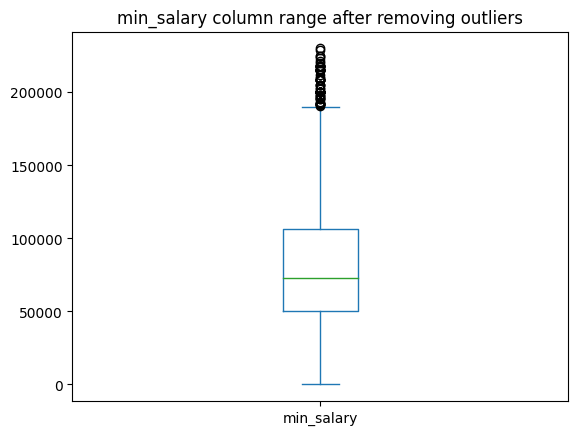

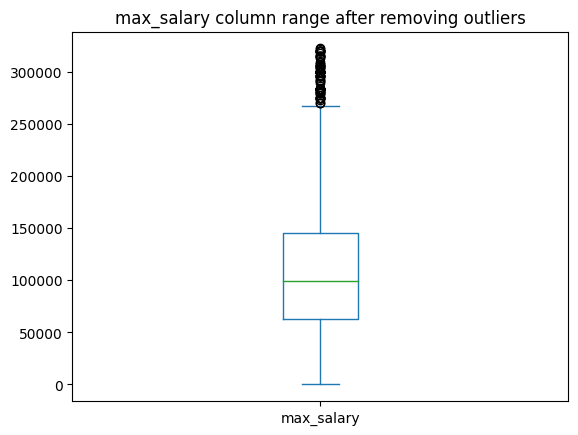

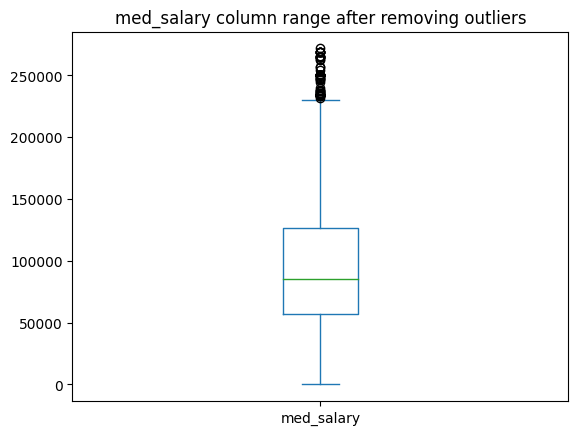

,job_id,company_id,title,description,max_salary,med_salary,min_salary,pay_period,formatted_work_type,location,...,expiry,closed_time,formatted_experience_level,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type
0,85008768,NaN,Licensed Insurance Agent,While many industries were hurt by the last fe...,52000.0,48880.0,45760.0,YEARLY,1,"Chico, CA",...,2024-03-09 16:00:00,NaT,NaN,NaN,2023-07-22 04:26:40,-1,1,1,USD,BASE_SALARY
5,903408693,3894635.0,Office Associate,Provide clerical and administrative support to...,42000.0,39500.0,37000.0,YEARLY,1,"Albany, GA",...,2024-03-09 16:00:00,NaT,NaN,NaN,2023-07-22 04:26:40,-1,1,1,USD,BASE_SALARY
8,1029078768,61469.0,Registered Nurse (RN) Vaccinator,United Staffing Solutions is partnering with o...,104000.0,104000.0,104000.0,YEARLY,4,"Muskegon, MI",...,2023-11-14 22:13:20,NaT,NaN,NaN,2023-07-22 04:26:40,-1,0,4,USD,BASE_SALARY
12,1535492735,NaN,Administrative Assistant,We are looking for a responsible Administrativ...,41600.0,39520.0,37440.0,YEARLY,4,"Ocoee, FL",...,2024-03-09 16:00:00,NaT,NaN,NaN,2023-07-22 04:26:40,-1,0,4,USD,BASE_SALARY
13,1657978824,89350959.0,"REMOTE STEEL BUILDING SALES MAKE $1,000 TO $30...","REMOTE WORK FROM HOME $1,000 TO $10,000 COMMIS...",144000.0,144000.0,144000.0,YEARLY,0,"Texas, United States",...,2024-03-09 16:00:00,NaT,NaN,NaN,2023-07-22 04:26:40,-1,0,0,USD,BASE_SALARY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15870,3701373383,13651.0,Senior Analyst,About Us\nMarketAxess is on a journey to digit...,85000.0,80000.0,75000.0,YEARLY,1,"New York, NY",...,2023-11-14 22:13:20,NaT,MID-SENIOR LEVEL,NaN,2023-07-22 04:26:40,79,0,1,USD,BASE_SALARY
15871,3701373385,18312164.0,Sales Manager,"Sales ManagerTexas, US $60,000–$70,000OTE $250...",70000.0,65000.0,60000.0,YEARLY,1,"Texas, United States",...,2023-11-14 22:13:20,NaT,MID-SENIOR LEVEL,NaN,2023-07-22 04:26:40,-1,0,1,USD,BASE_SALARY
15875,3701373427,1321042.0,Design Intern,Looking to redefine the skyline or to be a par...,49691.2,44688.8,39686.4,YEARLY,2,"Miramar, FL",...,2023-11-14 22:13:20,NaT,MID-SENIOR LEVEL,NaN,2023-07-22 04:26:40,1138,0,2,USD,BASE_SALARY
15878,3701373493,5619.0,Sr. Bilingual Copywriter (Canadian French),Overview\nTHE ROLE:\nThe Senior Bilingual Copy...,105200.0,98550.0,91900.0,YEARLY,1,"Torrance, CA",...,2023-11-14 22:13:20,NaT,MID-SENIOR LEVEL,NaN,2023-07-22 04:26:40,663,0,1,USD,BASE_SALARY


In [150]:
# removing outliers from salary columns so that it will not affect prediction in future using interquartile range.
def remove_outliers(dataframe, columnName):
    q1 = np.percentile(dataframe.loc[:, columnName], 25)
    q3 = np.percentile(dataframe.loc[:, columnName], 75)

    iqr_value = 1.5 * (q3 - q1)
    
    upper_bound = q3 + 1.5 * iqr_value
    lower_bound = q1 - 1.5 * iqr_value
    
    index_choose_lower = dataframe[(dataframe.loc[:, columnName] < lower_bound)].index
    dataframe.drop(index_choose_lower, inplace=True)

    index_choose_upper = dataframe[(dataframe.loc[:, columnName] > upper_bound)].index
    dataframe.drop(index_choose_upper, inplace=True)

# showing overall entries in min_salary, max_salary, med_salary column including outliers using box plot
job_postings_dataframe['min_salary'].plot(kind="box")
plt.title("min_salary column range")
plt.show()

job_postings_dataframe['max_salary'].plot(kind="box")
plt.title("max_salary column range")
plt.show()

job_postings_dataframe['med_salary'].plot(kind="box")
plt.title("med_salary column range")
plt.show()

# removed outlier using function defined above.
remove_outliers(job_postings_dataframe, 'max_salary')
remove_outliers(job_postings_dataframe, 'min_salary')
remove_outliers(job_postings_dataframe, 'med_salary')

# showing overall entries in min_salary after removing outliers using box-plot
job_postings_dataframe['min_salary'].plot(kind="box")
plt.title("min_salary column range after removing outliers")
plt.show()

job_postings_dataframe['max_salary'].plot(kind="box")
plt.title("max_salary column range after removing outliers")
plt.show()

job_postings_dataframe['med_salary'].plot(kind="box")
plt.title("med_salary column range after removing outliers")
plt.show()

job_postings_dataframe

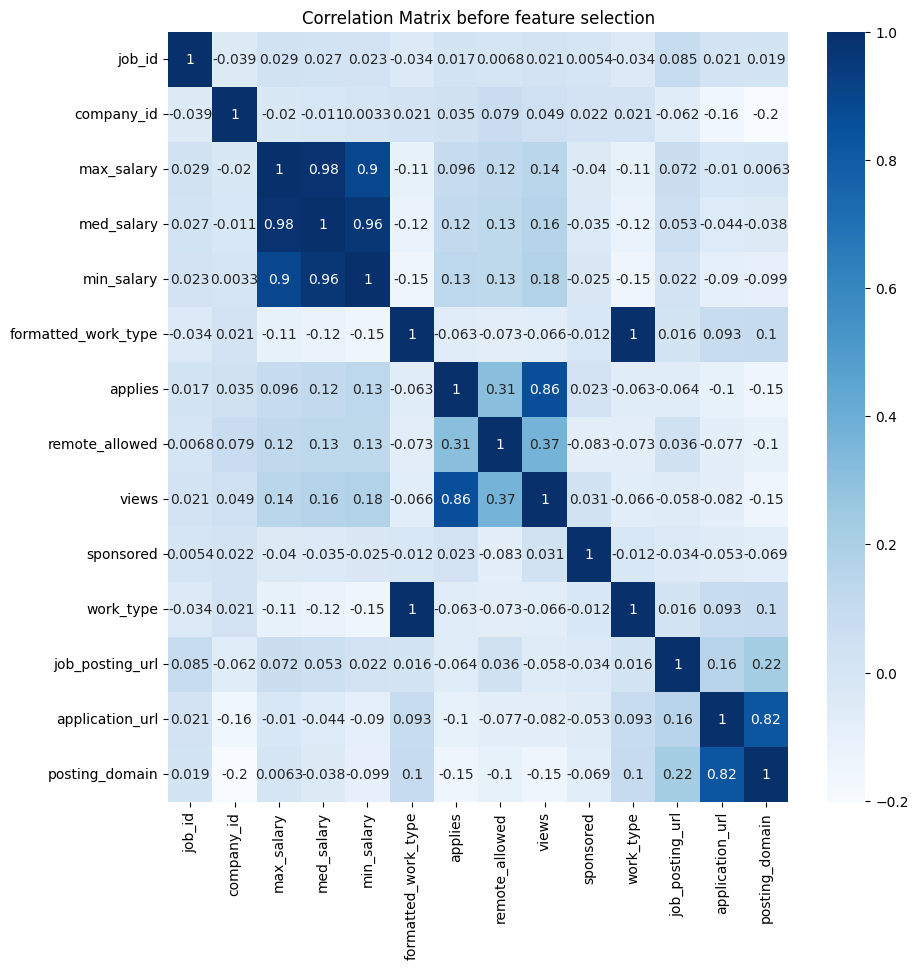

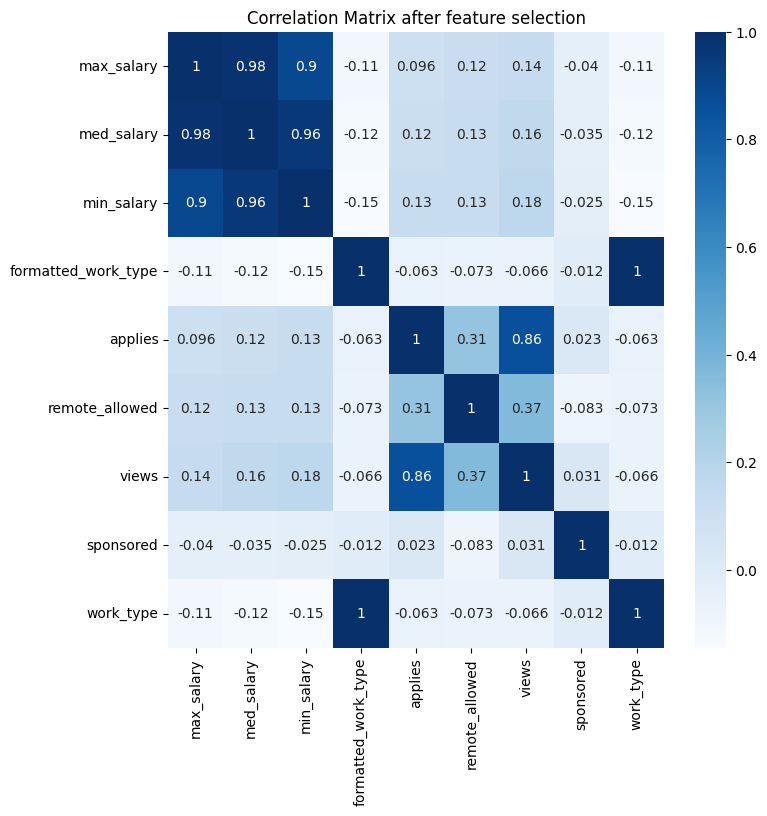

,title,description,max_salary,med_salary,min_salary,pay_period,formatted_work_type,location,applies,original_listed_time,...,application_type,expiry,closed_time,formatted_experience_level,skills_desc,listed_time,sponsored,work_type,currency,compensation_type
0,Licensed Insurance Agent,While many industries were hurt by the last fe...,52000.0,48880.0,45760.0,YEARLY,1,"Chico, CA",0.0,2023-07-22 04:26:40,...,COMPLEXONSITEAPPLY,2024-03-09 16:00:00,NaT,NaN,NaN,2023-07-22 04:26:40,1,1,USD,BASE_SALARY
5,Office Associate,Provide clerical and administrative support to...,42000.0,39500.0,37000.0,YEARLY,1,"Albany, GA",5.0,2023-07-22 04:26:40,...,COMPLEXONSITEAPPLY,2024-03-09 16:00:00,NaT,NaN,NaN,2023-07-22 04:26:40,1,1,USD,BASE_SALARY
8,Registered Nurse (RN) Vaccinator,United Staffing Solutions is partnering with o...,104000.0,104000.0,104000.0,YEARLY,4,"Muskegon, MI",0.0,2023-07-22 04:26:40,...,COMPLEXONSITEAPPLY,2023-11-14 22:13:20,NaT,NaN,NaN,2023-07-22 04:26:40,0,4,USD,BASE_SALARY
12,Administrative Assistant,We are looking for a responsible Administrativ...,41600.0,39520.0,37440.0,YEARLY,4,"Ocoee, FL",3.0,2023-07-22 04:26:40,...,COMPLEXONSITEAPPLY,2024-03-09 16:00:00,NaT,NaN,NaN,2023-07-22 04:26:40,0,4,USD,BASE_SALARY
13,"REMOTE STEEL BUILDING SALES MAKE $1,000 TO $30...","REMOTE WORK FROM HOME $1,000 TO $10,000 COMMIS...",144000.0,144000.0,144000.0,YEARLY,0,"Texas, United States",0.0,2023-07-22 04:26:40,...,OFFSITEAPPLY,2024-03-09 16:00:00,NaT,NaN,NaN,2023-07-22 04:26:40,0,0,USD,BASE_SALARY
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15870,Senior Analyst,About Us\nMarketAxess is on a journey to digit...,85000.0,80000.0,75000.0,YEARLY,1,"New York, NY",14.0,2023-07-22 04:26:40,...,OFFSITEAPPLY,2023-11-14 22:13:20,NaT,MID-SENIOR LEVEL,NaN,2023-07-22 04:26:40,0,1,USD,BASE_SALARY
15871,Sales Manager,"Sales ManagerTexas, US $60,000–$70,000OTE $250...",70000.0,65000.0,60000.0,YEARLY,1,"Texas, United States",7.0,2023-07-22 04:26:40,...,OFFSITEAPPLY,2023-11-14 22:13:20,NaT,MID-SENIOR LEVEL,NaN,2023-07-22 04:26:40,0,1,USD,BASE_SALARY
15875,Design Intern,Looking to redefine the skyline or to be a par...,49691.2,44688.8,39686.4,YEARLY,2,"Miramar, FL",2.0,2023-07-22 04:26:40,...,OFFSITEAPPLY,2023-11-14 22:13:20,NaT,MID-SENIOR LEVEL,NaN,2023-07-22 04:26:40,0,2,USD,BASE_SALARY
15878,Sr. Bilingual Copywriter (Canadian French),Overview\nTHE ROLE:\nThe Senior Bilingual Copy...,105200.0,98550.0,91900.0,YEARLY,1,"Torrance, CA",4.0,2023-07-22 04:26:40,...,OFFSITEAPPLY,2023-11-14 22:13:20,NaT,MID-SENIOR LEVEL,NaN,2023-07-22 04:26:40,0,1,USD,BASE_SALARY


In [151]:
# This heatmap shows the correlation between all the numerical columns of the dataset.
numerical_columns = job_postings_dataframe[['job_id', 'company_id', 'max_salary', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 
                                            'remote_allowed', 'views', 'sponsored', 'work_type', 'job_posting_url', 'application_url', 'posting_domain']]
job_posting_correlation = numerical_columns.corr()
plt.figure(figsize = (10,10))
sns.heatmap(job_posting_correlation, annot=True, cmap="Blues")
plt.title("Correlation Matrix before feature selection")
plt.show()

# dropping not required columns to perform dimensionality reduction
job_postings_dataframe.drop(columns=['job_posting_url', 'application_url', 'posting_domain', 'job_id', 'company_id'], axis=1, inplace=True)

# This heatmap shows the correlation between all the numerical columns of the dataset.
numerical_columns = job_postings_dataframe[['max_salary', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 
                                            'remote_allowed', 'views', 'sponsored', 'work_type']]
job_posting_correlation = numerical_columns.corr()
plt.figure(figsize = (8,8))
sns.heatmap(job_posting_correlation, annot=True, cmap="Blues")
plt.title("Correlation Matrix after feature selection")
plt.show()

job_postings_dataframe

In [152]:
# creating a csv file for cleaned data
job_postings_dataframe.to_csv("job_postings_cleaned.csv", index=False)

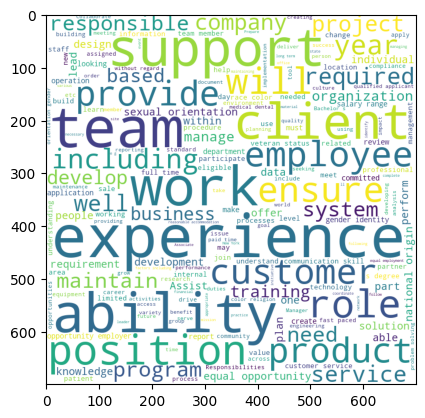

<Figure size 1000x1000 with 0 Axes>

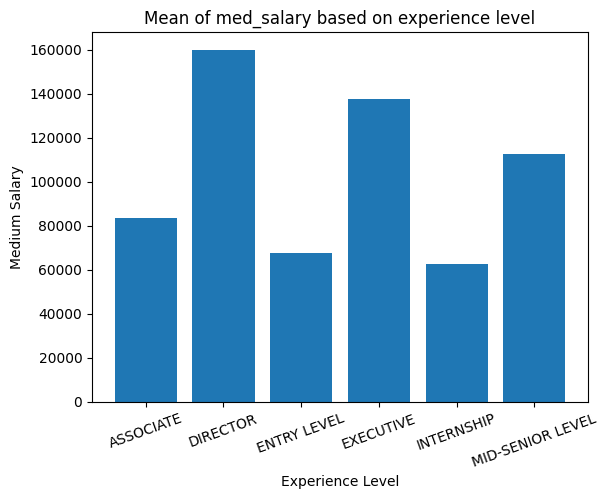

/var/folders/hb/ssfbyj0d6gvd1dv6sbyk12n80000gn/T/ipykernel_18194/3304659337.py:16: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(job_postings_dataframe['formatted_experience_level']).plot.bar()


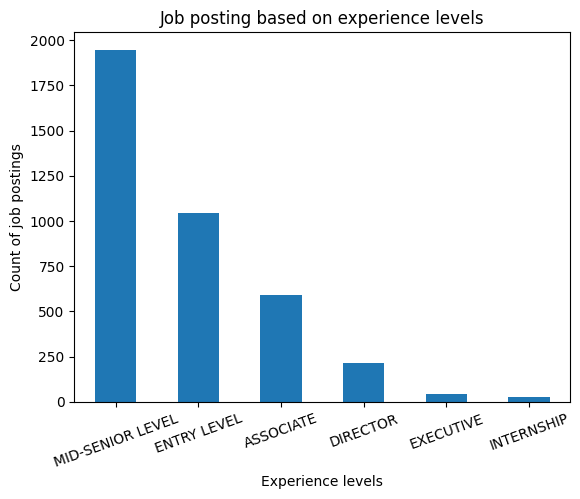

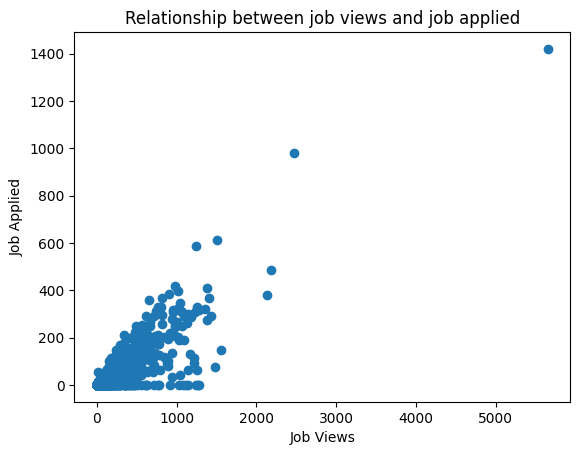

In [153]:
# this word cloud shows the commonly used words in description column 
wordcloud = WordCloud(width=700, height=700, background_color='White').generate(' '.join(job_postings_dataframe['description']))
plt.imshow(wordcloud)
plt.figure(figsize=(10, 10))
plt.show()

job_posting_experience = job_postings_dataframe.groupby("formatted_experience_level")[["med_salary"]].mean()
plt.bar(job_posting_experience.index, job_posting_experience['med_salary'])
plt.title("Mean of med_salary based on experience level")
plt.xlabel("Experience Level")
plt.xticks(rotation=20)
plt.ylabel("Medium Salary")
plt.show()

# This bar graph shows the number of job postings based on experience levels
pd.value_counts(job_postings_dataframe['formatted_experience_level']).plot.bar()
plt.title("Job posting based on experience levels")
plt.xlabel("Experience levels")
plt.xticks(rotation=20)
plt.ylabel("Count of job postings")
plt.show()

x = job_postings_dataframe['views']
y = job_postings_dataframe['applies']
plt.scatter(x, y)
plt.title("Relationship between job views and job applied")
plt.xlabel("Job Views")
plt.ylabel("Job Applied")
plt.show()


# Project Phase 2

In [154]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, mean_absolute_error, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVR

In [155]:
# fetching the data and creating dataFrame
job_postings_dataset = pd.read_csv("job_postings_cleaned.csv")
job_postings_dataframe = pd.DataFrame(job_postings_dataset)

# checking the information of dataframe
job_postings_dataframe.info()

# finding the number of fetaures and rows of the data
print()
print("Shape of the dataframe: ", job_postings_dataframe.shape)
print()

#  finding the statistic of the given dataset for better analysis
job_postings_dataframe.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5455 entries, 0 to 5454
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   title                       5455 non-null   object 
 1   description                 5455 non-null   object 
 2   max_salary                  5455 non-null   float64
 3   med_salary                  5455 non-null   float64
 4   min_salary                  5455 non-null   float64
 5   pay_period                  5455 non-null   object 
 6   formatted_work_type         5455 non-null   int64  
 7   location                    5455 non-null   object 
 8   applies                     5455 non-null   float64
 9   original_listed_time        5455 non-null   object 
 10  remote_allowed              5455 non-null   float64
 11  views                       5455 non-null   float64
 12  application_type            5455 non-null   object 
 13  expiry                      5455 

,max_salary,med_salary,min_salary,formatted_work_type,applies,remote_allowed,views,sponsored,work_type
count,5455.000000,5455.000000,5455.000000,5455.000000,5455.000000,5455.000000,5455.000000,5455.000000,5455.000000
mean,110240.976011,96043.157257,81845.338502,1.024198,17.041613,0.161320,83.548488,0.312741,1.024198
std,59122.344604,48886.989147,41194.643292,0.739529,47.110551,0.367859,180.932624,0.463652,0.739529
min,15.000000,13.500000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,62500.000000,57200.000000,50000.000000,1.000000,0.000000,0.000000,5.000000,0.000000,1.000000
50%,99200.000000,85000.000000,72800.000000,1.000000,2.000000,0.000000,27.000000,0.000000,1.000000
75%,145000.000000,126865.000000,106000.000000,1.000000,13.000000,0.000000,87.000000,1.000000,1.000000
max,322500.000000,271850.000000,230000.000000,5.000000,1420.000000,1.000000,5656.000000,1.000000,5.000000


In [156]:
# Filling empty columns of experience level based on title, description, minimum salary
def fill_experience_level_title(job_title):
    if 'director' in job_title.lower():
        return 'DIRECTOR'
    elif 'manager' in job_title.lower():
        return 'MID-SENIOR LEVEL'
    elif 'senior' in job_title.lower() or 'specialist' in job_title.lower() or 'sr' in job_title.lower():
        return 'SENIOR LEVEL'
    elif 'associate' in job_title.lower() or 'I' in job_title.lower() or 'clerk' in job_title.lower() or 'assistant' in job_title.lower() or 'jr' in job_title.lower()or 'analyst' in job_title.lower() or 'junior' in job_title.lower() or 'administrator' in job_title.lower():
        return 'ENTRY LEVEL'
    elif 'intern' in job_title.lower():
        return 'INTERNSHIP'
    elif 'owner' in job_title.lower():
        return 'CEO'
    elif 'executive' in job_title.lower():
        return 'EXECUTIVE'
    

def fill_experience_level_description(description):
    if 'director' in description.lower():
        return 'DIRECTOR'
    elif 'manager' in description.lower() or 'III' in description.lower():
        return 'MID-SENIOR LEVEL'
    elif 'senior' in description.lower() or 'specialist' in description.lower() or 'sr' in description.lower() or 'II' in description.lower():
        return 'SENIOR LEVEL'
    elif 'associate' in description.lower() or 'I' in description.lower() or 'clerk' in description.lower() or 'assistant' in description.lower() or 'jr' in description.lower()or 'analyst' in description.lower() or 'junior' in description.lower() or 'administrator' in description.lower():
        return 'ENTRY LEVEL'
    elif 'intern' in description.lower():
        return 'INTERNSHIP'
    elif 'owner' in description.lower():
        return 'CEO'
    elif 'executive' in description.lower():
        return 'EXECUTIVE'
    
def fill_experience_level_salary(salary):
    if salary > 100000:
        return 'MID-SENIOR LEVEL'
    elif salary > 60000 and salary <= 100000:
        return 'SENIOR LEVEL'
    elif salary <= 60000:
        return 'ENTRY LEVEL'
    

job_postings_dataframe['formatted_experience_level'] = job_postings_dataframe.apply(
    lambda row: fill_experience_level_description(row['title']) if pd.isna(row['formatted_experience_level']) else row['formatted_experience_level'],
    axis=1
)

job_postings_dataframe['formatted_experience_level'] = job_postings_dataframe.apply(
    lambda row: fill_experience_level_description(row['description']) if pd.isna(row['formatted_experience_level']) else row['formatted_experience_level'],
    axis=1
)

job_postings_dataframe['formatted_experience_level'] = job_postings_dataframe.apply(
    lambda row: fill_experience_level_salary(row['min_salary']) if pd.isna(row['formatted_experience_level']) else row['formatted_experience_level'],
    axis=1
)

# Encoding categorical values using Label encoding
job_postings_dataframe.loc[:, 'formatted_experience_level_label_encoding'] = job_postings_dataframe.loc[:, 'formatted_experience_level'].astype('category').cat.codes
job_postings_dataframe.loc[:, 'application_type_label_encoding'] = job_postings_dataframe.loc[:, 'application_type'].astype('category').cat.codes

# creating a csv file for cleaned data
job_postings_dataframe.to_csv("job_postings_filled.csv", index=False)

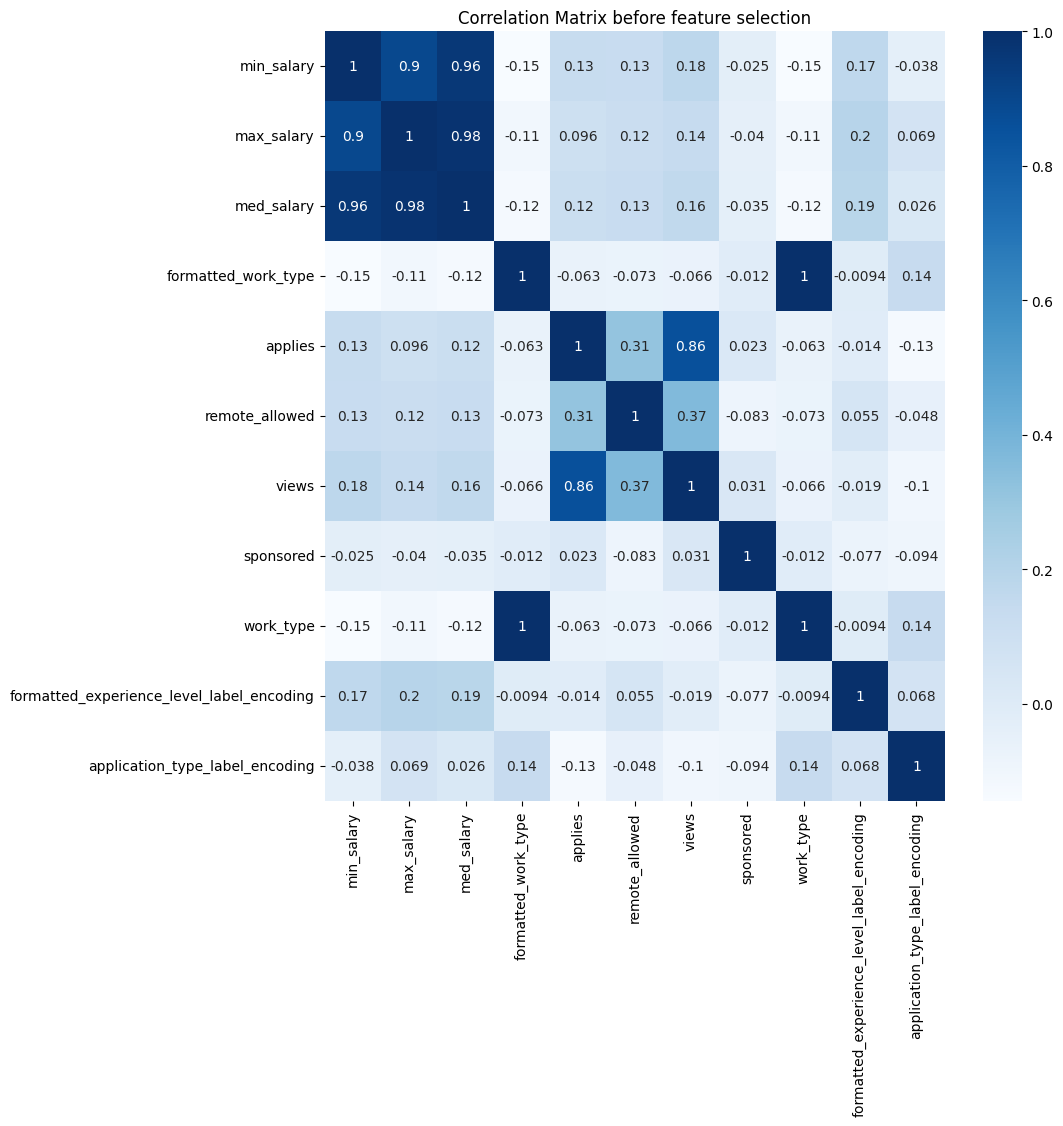

In [157]:
# Plotting correlation matrix to evaluate relationship between features
numerical_columns = job_postings_dataframe[['min_salary', 'max_salary', 'med_salary', 'formatted_work_type', 'applies', 'remote_allowed', 'views', 'sponsored', 'work_type', 'formatted_experience_level_label_encoding', 'application_type_label_encoding']]
job_posting_correlation = numerical_columns.corr()
plt.figure(figsize = (10,10))
sns.heatmap(job_posting_correlation, annot=True, cmap="Blues")
plt.title("Correlation Matrix before feature selection")
plt.show()

In [169]:
# Deciding the columns for features and target variables
selected_features = ['min_salary', 'formatted_work_type', 'remote_allowed', 'formatted_experience_level_label_encoding', 'application_type_label_encoding']
X_data = job_postings_dataframe[selected_features]
Y_target = job_postings_dataframe['max_salary']

print("X_data Shape: ", X_data.shape)
print("Y_target Shape: ", Y_target.shape)

# Splitting training and testing data into 80% and 20%
X_train, X_test, y_train, y_test = train_test_split(X_data, Y_target, test_size=0.2, random_state=0)

print()
print("X Training Shape: ", X_train.shape)
print("Y Training Shape: ", y_train.shape)
print("X Testing Shape: ", X_test.shape)
print("Y Testing Shape: ", y_test.shape)


X_data Shape:  (5455, 5)
Y_target Shape:  (5455,)

X Training Shape:  (4364, 5)
Y Training Shape:  (4364,)
X Testing Shape:  (1091, 5)
Y Testing Shape:  (1091,)


[110017.76031162 114429.90994219  85822.72916797 ...  39861.18393229
 121384.29251645 224502.48583638]
Linear Regression R2 Score:  0.8059473324424739
Linear Regression Mean Squared Error:  693823065.9731591
Linear Regression Mean Absolute Error:  18010.987603599853
Linear Regression Accuracy:  80.59473324424738


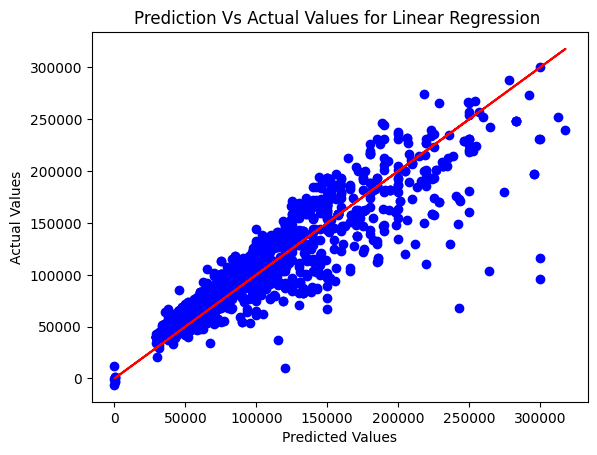

In [159]:
# Linear Regression - predicting min_salary based on the feature columns
linear_regression_model = LinearRegression()
linear_regression_model.fit(X_train, y_train)

y_predicted_linear = linear_regression_model.predict(X_test)
print(y_predicted_linear)

linear_regression_r2_squared = r2_score(y_test, y_predicted_linear)
print("Linear Regression R2 Score: ", linear_regression_r2_squared)

linear_regression_mse = mean_squared_error(y_test, y_predicted_linear)
print("Linear Regression Mean Squared Error: ", linear_regression_mse)

linear_regression_mae = mean_absolute_error(y_test, y_predicted_linear)
print("Linear Regression Mean Absolute Error: ", linear_regression_mae)

linear_regression_accuracy = linear_regression_r2_squared * 100
print("Linear Regression Accuracy: ", linear_regression_accuracy)

plt.scatter(y_test, y_predicted_linear, color='blue')
plt.plot(y_test,y_test,color = 'red')
plt.title("Prediction Vs Actual Values for Linear Regression ")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.show()

In [195]:
# Deciding the columns for features and target variables
selected_features = ['min_salary', 'formatted_work_type', 'remote_allowed', 'application_type_label_encoding']
X_data = job_postings_dataframe[selected_features]
Y_target = job_postings_dataframe['formatted_experience_level_label_encoding']

print("X_data Shape: ", X_data.shape)
print("Y_target Shape: ", Y_target.shape)

# Splitting training and testing data into 80% and 20%
X_train, X_test, y_train, y_test = train_test_split(X_data, Y_target, test_size=0.2, random_state=0)

print()
print("X Training Shape: ", X_train.shape)
print("Y Training Shape: ", y_train.shape)
print("X Testing Shape: ", X_test.shape)
print("Y Testing Shape: ", y_test.shape)

X_data Shape:  (5455, 4)
Y_target Shape:  (5455,)

X Training Shape:  (4364, 4)
Y Training Shape:  (4364,)
X Testing Shape:  (1091, 4)
Y Testing Shape:  (1091,)


[3.25294643 2.924625   3.9073446  ... 2.98227464 3.66732918 3.89492857]
Random Forest R2 Score:  0.04881204614764867
Random Forest Mean Squared Error:  1.6000912001125218
Random Forest Mean Absolute Error:  1.6000912001125218
Random Forest Accuracy:  4.881204614764867


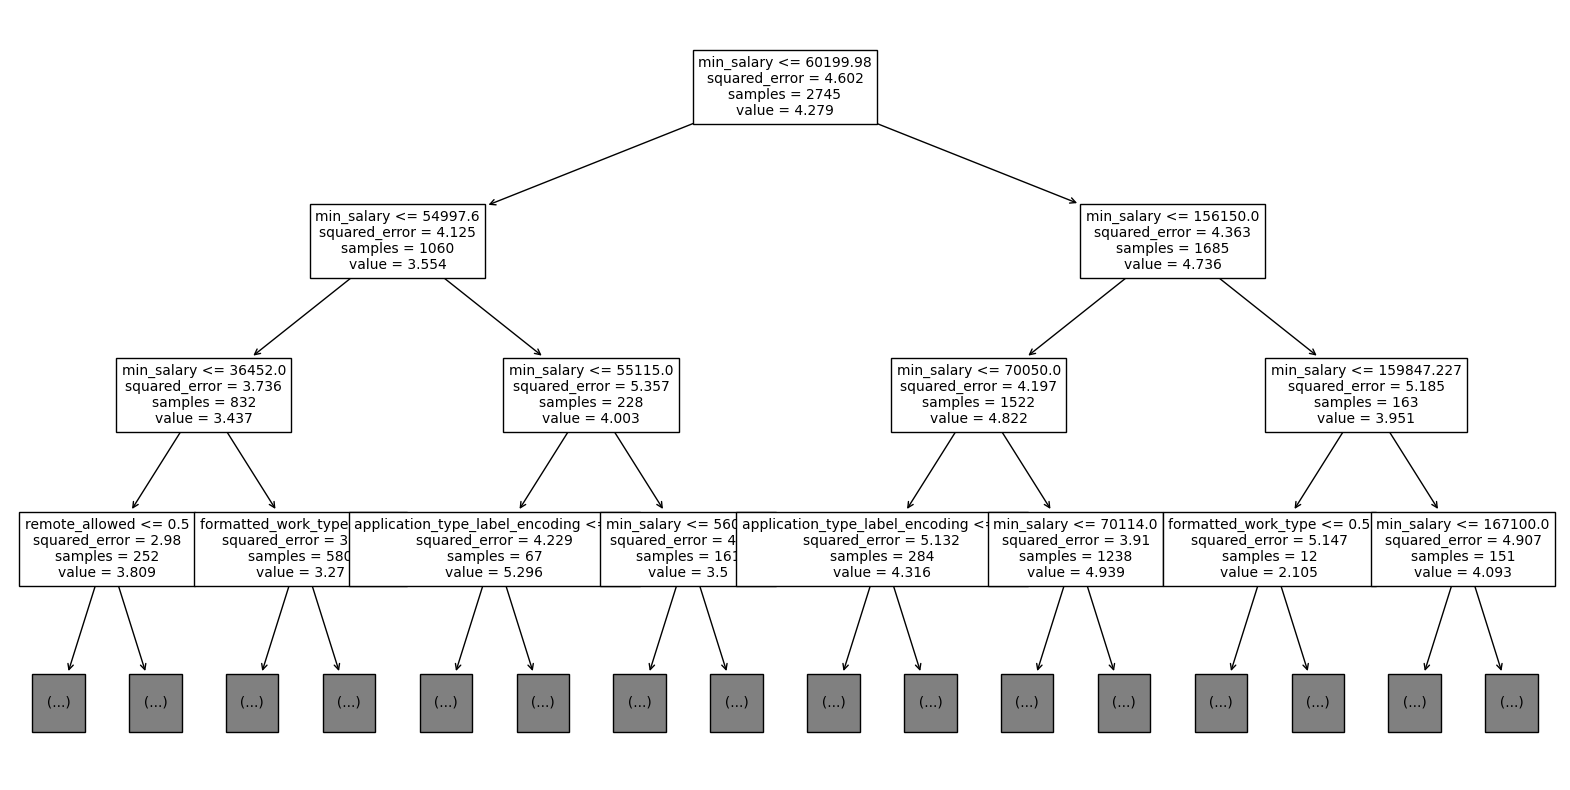

In [196]:
# Random Forest - predicting min_salary based on the feature columns (better performance)
random_forest_model = RandomForestRegressor(n_estimators=200, random_state=100)
random_forest_model.fit(X_train, y_train)

y_predicted_random_forest = random_forest_model.predict(X_test)
print(y_predicted_random_forest)

random_forest_r2_squared = r2_score(y_test, y_predicted_random_forest)
print("Random Forest R2 Score: ", random_forest_r2_squared)

random_forest_mse = mean_absolute_error(y_test, y_predicted_random_forest)
print("Random Forest Mean Squared Error: ", random_forest_mse)

random_forest_mae = mean_absolute_error(y_test, y_predicted_random_forest)
print("Random Forest Mean Absolute Error: ", random_forest_mae)

random_forest_accuracy = random_forest_r2_squared * 100
print("Random Forest Accuracy: ", random_forest_accuracy)


tree = random_forest_model.estimators_[0]
feature_list = X_train.columns.tolist()

plt.figure(figsize=(20,10))
plot_tree(tree, feature_names=feature_list, max_depth=3, fontsize=10)
plt.show()

In [178]:
# Deciding the columns for features and target variables
selected_columns = ['min_salary', 'formatted_work_type', 'sponsored', 'formatted_experience_level_label_encoding', 'application_type_label_encoding', "applies", "views"]
X_data_selected_column = job_postings_dataframe[selected_columns]


X Training Shape:  (3273, 7)
Y Training Shape:  (3273,)
X Testing Shape:  (2182, 7)
Y Testing Shape:  (2182,)
[0. 0. 0. ... 0. 0. 0.]
Logistic Regression Accuracy:  85.33455545371218


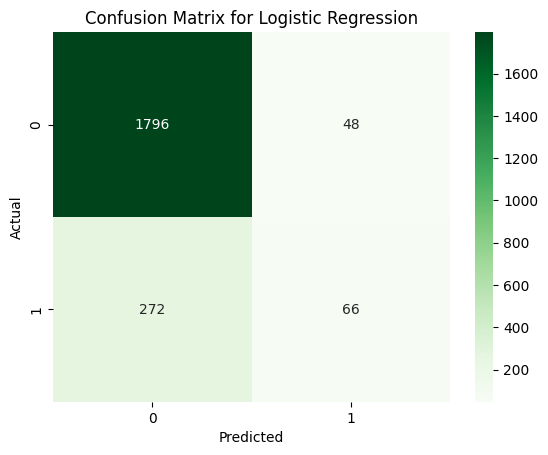

In [179]:
# Logistic Regression - predicting remote_allowed based on features
Y_target_logistic = job_postings_dataframe['remote_allowed']

X_train_logistic, X_test_logistic, y_train_logistic, y_test_logistic = train_test_split(X_data_selected_column, Y_target_logistic, test_size=0.4, random_state=0)

print()
print("X Training Shape: ", X_train_logistic.shape)
print("Y Training Shape: ", y_train_logistic.shape)
print("X Testing Shape: ", X_test_logistic.shape)
print("Y Testing Shape: ", y_test_logistic.shape)

logistic_regression_model = LogisticRegression(max_iter=500)
logistic_regression_model.fit(X_train_logistic, y_train_logistic)

y_predicted_logistic = logistic_regression_model.predict(X_test_logistic)
print(y_predicted_logistic)

logistic_regression_accuracy = accuracy_score(y_test_logistic, y_predicted_logistic)
print("Logistic Regression Accuracy: ", logistic_regression_accuracy*100)

confusion_matrix_logistic = confusion_matrix(y_test_logistic, y_predicted_logistic)
sns.heatmap(confusion_matrix_logistic, annot=True, fmt='d', cmap="Greens")
plt.title("Confusion Matrix for Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [163]:
selected_columns = ['min_salary', 'formatted_work_type', 'remote_allowed', 'sponsored', 'work_type', 'formatted_experience_level_label_encoding', 'application_type_label_encoding']
X_data_selected_column = job_postings_dataframe[selected_columns]

In [164]:
selected_features = ['min_salary', 'formatted_work_type', 'remote_allowed', 'formatted_experience_level_label_encoding', 'application_type_label_encoding']
X_data = job_postings_dataframe[selected_features]
Y_target = job_postings_dataframe['max_salary']

[1 1 1 ... 1 1 1]
KNN Accuracy:  93.12557286892759


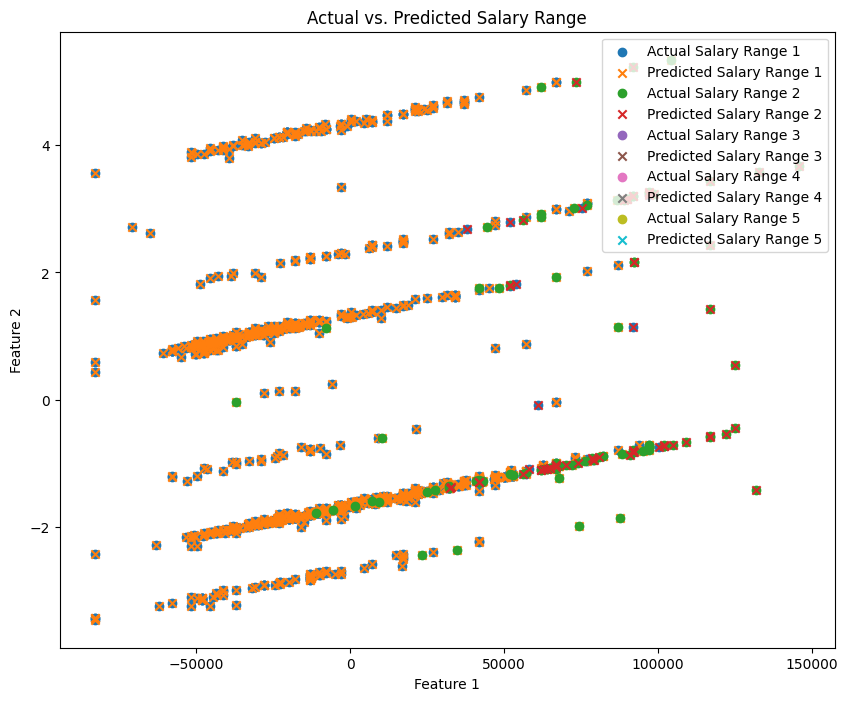

In [165]:
# K-Nearest Neightbours - Classifying min_salary_range
salary_bins = [0, 200000, 400000, 600000, 800000, 1500000]
salary_labels = [1, 2, 3, 4, 5]
job_postings_dataframe['max_salary_range'] = pd.cut(job_postings_dataframe['max_salary'], bins=salary_bins, labels=salary_labels)

Y_target_knn = job_postings_dataframe['max_salary_range']

X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(X_data_selected_column, Y_target_knn, test_size=0.2, random_state=0)

knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train_knn, y_train_knn)

y_predicted_knn = knn_model.predict(X_test_knn)
print(y_predicted_knn)

knn_accuracy = accuracy_score(y_test_knn, y_predicted_knn)
print("KNN Accuracy: ", knn_accuracy*100)

pca_knn = PCA(n_components=2)
X_reduced_knn = pca_knn.fit_transform(X_test_knn)

plt.figure(figsize=(10, 8))

for label in (salary_labels):
    actual_salary_label = y_test_knn == label
    predicted_salary_label = y_predicted_knn == label
    
    plt.scatter(X_reduced_knn[actual_salary_label, 0], X_reduced_knn[actual_salary_label, 1], label=f'Actual Salary Range {label}')
    plt.scatter(X_reduced_knn[predicted_salary_label, 0], X_reduced_knn[predicted_salary_label, 1], marker='x', label=f'Predicted Salary Range {label}')

plt.title('Actual vs. Predicted Salary Range')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

In [199]:
selected_columns_nb = ['min_salary', 'remote_allowed', 'sponsored', 'application_type_label_encoding', 'formatted_experience_level_label_encoding']
X_data_nb = job_postings_dataframe[selected_columns_nb]
Y_target_nb = job_postings_dataframe['formatted_work_type']

X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(X_data_nb, Y_target_nb, test_size=0.8, random_state=0)


naive_bayes_model = GaussianNB()
naive_bayes_model.fit(X_train_nb, y_train_nb)
y_predicted_nb =  naive_bayes_model.predict(X_test_nb)

naive_bayes_accuracy = accuracy_score(y_test_nb, y_predicted_nb)
print("Naive Bayes Accuracy: ", naive_bayes_accuracy*100)

Naive Bayes Accuracy:  83.86801099908341



X Training Shape:  (1091, 5)
Y Training Shape:  (1091,)
X Testing Shape:  (4364, 5)
Y Testing Shape:  (4364,)
Naive Bayes Accuracy:  83.86801099908341


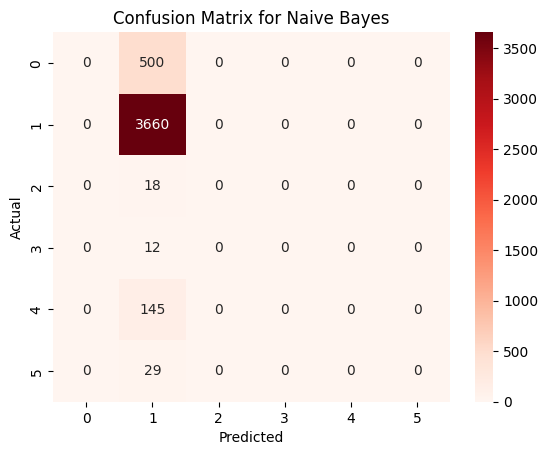

In [198]:
# Naive Bayes - Classification of Work Types based on feature columns
selected_columns_nb = ['min_salary', 'remote_allowed', 'sponsored', 'application_type_label_encoding', 'formatted_experience_level_label_encoding']
X_data_nb = job_postings_dataframe[selected_columns_nb]
Y_target_nb = job_postings_dataframe['formatted_work_type']

X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(X_data_nb, Y_target_nb, test_size=0.8, random_state=0)

print()
print("X Training Shape: ", X_train_nb.shape)
print("Y Training Shape: ", y_train_nb.shape)
print("X Testing Shape: ", X_test_nb.shape)
print("Y Testing Shape: ", y_test_nb.shape)


naive_bayes_model = GaussianNB()
naive_bayes_model.fit(X_train_nb, y_train_nb)
y_predicted_nb =  naive_bayes_model.predict(X_test_nb)

naive_bayes_accuracy = accuracy_score(y_test_nb, y_predicted_nb)
print("Naive Bayes Accuracy: ", naive_bayes_accuracy*100)

confusion_matrix_nb = confusion_matrix(y_test_nb, y_predicted_nb)
sns.heatmap(confusion_matrix_nb, annot=True, fmt='d', cmap="Reds")
plt.title("Confusion Matrix for Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


X Training Shape:  (4364, 7)
Y Training Shape:  (4364,)
X Testing Shape:  (1091, 7)
Y Testing Shape:  (1091,)
SVR R2 Score:  0.8486903083406847
SVR Mean Squared Error:  8.051662552882183
SVR Mean Absolute Error:  8.051662552882183
SVR Accuracy:  84.86903083406847


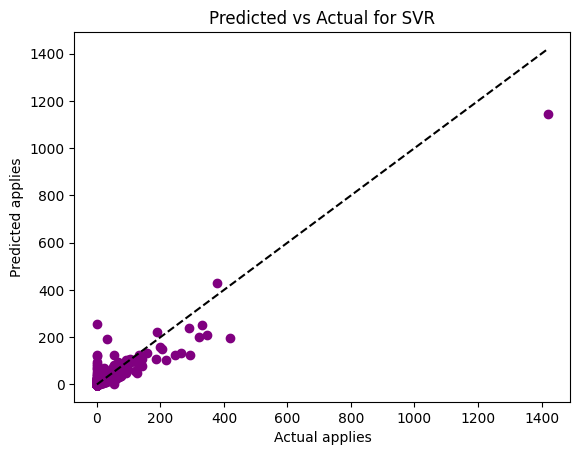

In [167]:
# Support Vector Regression - Predicting number of applications based on features
selected_columns_nn = ['min_salary', 'max_salary', 'med_salary', 'remote_allowed', 'views', 'formatted_experience_level_label_encoding', 'application_type_label_encoding']
X_data_svr = job_postings_dataframe[selected_columns_nn]
Y_target_svr = job_postings_dataframe['applies']

X_train_svr, X_test_svr, y_train_svr, y_test_svr = train_test_split(X_data_svr, Y_target_svr, test_size=0.2, random_state=0)

print()
print("X Training Shape: ", X_train_svr.shape)
print("Y Training Shape: ", y_train_svr.shape)
print("X Testing Shape: ", X_test_svr.shape)
print("Y Testing Shape: ", y_test_svr.shape)

scaler = StandardScaler()
X_trained_svr_scaled = scaler.fit_transform(X_train_svr)
X_test_svr_scaled = scaler.transform(X_test_svr)

svr_model = SVR(kernel='linear')
svr_model.fit(X_trained_svr_scaled, y_train_svr)

y_predicted_svr = svr_model.predict(X_test_svr_scaled)

svr_r2_squared = r2_score(y_test_svr, y_predicted_svr)
print("SVR R2 Score: ", svr_r2_squared)

svr_mse = mean_absolute_error(y_test_svr, y_predicted_svr)
print("SVR Mean Squared Error: ", svr_mse)

svr_mae = mean_absolute_error(y_test_svr, y_predicted_svr)
print("SVR Mean Absolute Error: ", svr_mae)

svr_accuracy = svr_r2_squared * 100
print("SVR Accuracy: ", svr_accuracy)

plt.scatter(y_test_svr, y_predicted_svr, color='purple')
plt.plot([Y_target_svr.min(), Y_target_svr.max()], [Y_target_svr.min(), Y_target_svr.max()], 'k--')
plt.xlabel('Actual applies')
plt.ylabel('Predicted applies')
plt.title('Predicted vs Actual for SVR')
plt.show()

In [168]:
# Gradient Boosting Regressor - Predicting minimum salary based on features
gradient_boosting_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.07, max_depth=3, random_state=100)
gradient_boosting_model.fit(X_train, y_train)

y_predicted_gradient_boosting = gradient_boosting_model.predict(X_test)
print(y_predicted_gradient_boosting)

gradient_boosting_r2_squared = r2_score(y_test, y_predicted_gradient_boosting)
print("Gradient Boosting Regressor R2 Score: ", gradient_boosting_r2_squared)

gradient_boosting_mse = mean_absolute_error(y_test, y_predicted_gradient_boosting)
print("Gradient Boosting Regressor Mean Squared Error: ", gradient_boosting_mse)

gradient_boosting_mae = mean_absolute_error(y_test, y_predicted_gradient_boosting)
print("Gradient Boosting Regressor Mean Absolute Error: ", gradient_boosting_mae)

gradient_boosting_accuracy = gradient_boosting_r2_squared * 100
print("Gradient Boosting Regressor Accuracy: ", gradient_boosting_accuracy)

[113009.70822105 125713.75925409  83645.99970422 ...  45931.1524029
 125610.3619102  221029.61427926]
Gradient Boosting Regressor R2 Score:  0.8336894078937606
Gradient Boosting Regressor Mean Squared Error:  16665.416027994615
Gradient Boosting Regressor Mean Absolute Error:  16665.416027994615
Gradient Boosting Regressor Accuracy:  83.36894078937605
